In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

In [4]:
df = pd.read_csv(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\cleaned_data\cleaned_superset.csv")

In [5]:
df.head()

,CSGroup,Profit Ratio,Category,City,Country,Customer Name,Discount,Number of Records,Order Date,Order ID,...,Ship Date,Ship Mode,State,Sub-Category (group) 2,Sub-Category (group) 3,Sub-Category (group) 4,Sub-Category (group) 5,Sub-Category (group) 6,Sub-Category (group),Sub-Category
0,A&B,16.0,Furniture,Henderson,United States,Claire Gute,0.0,1,2017-11-08,CA-2017-152156,...,2017-11-11,Second Class,Kentucky,Losses,Losses,Losses,"Bookcases, Supplies, Tables","Bookcases, Supplies, Tables","Bookcases, Supplies, Tables",Bookcases
1,CEF,30.0,Furniture,Henderson,United States,Claire Gute,0.0,1,2017-11-08,CA-2017-152156,...,2017-11-11,Second Class,Kentucky,High Profits,Profits,Profits,Chairs,Chairs,Rest,Chairs
2,Rest,47.0,Office Supplies,Los Angeles,United States,Darrin Van Huff,0.0,1,2017-06-12,CA-2017-138688,...,2017-06-16,Second Class,California,Less Profit,Profits,Profits,Labels,Labels,Rest,Labels
3,Rest,-40.0,Furniture,Fort Lauderdale,United States,Sean O'Donnell,45.0,1,2016-10-11,US-2016-108966,...,2016-10-18,Standard Class,Florida,Losses,Losses,Losses,"Bookcases, Supplies, Tables","Bookcases, Supplies, Tables","Bookcases, Supplies, Tables",Tables
4,Rest,11.0,Office Supplies,Fort Lauderdale,United States,Sean O'Donnell,20.0,1,2016-10-11,US-2016-108966,...,2016-10-18,Standard Class,Florida,High Profits,Profits,Profits,Storage,Storage,Rest,Storage


In [6]:
# Calculate the Main KPIs

In [7]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order ID"].nunique()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Total Orders: {total_orders}")

Total Sales: $2,297,073.00
Total Profit: $286,359.00
Total Quantity Sold: 37871
Total Orders: 5009


In [8]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         836221.0
Furniture          741725.0
Office Supplies    719127.0
Name: Sales, dtype: float64

In [9]:
# SALES BY CATEGORY

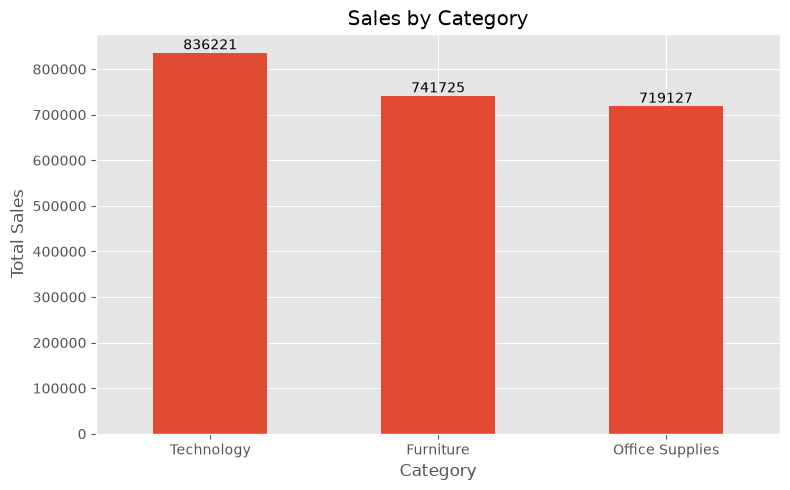

In [64]:
plt.figure(figsize=(8,5))

ax = category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\sales_by_category.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
# Profit by Category

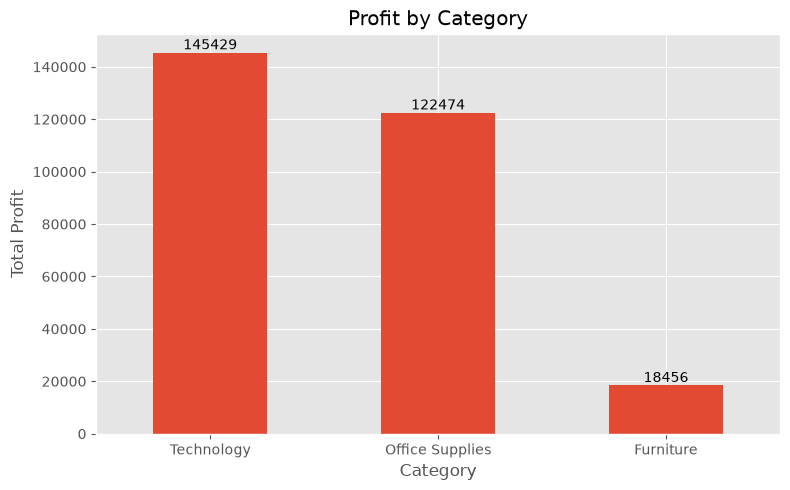

In [65]:
profit_by_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
### Business Insight
'''
- Technology generated the highest profit.
- Furniture generated comparatively lower profit despite high sales.
- The company should investigate Furniture margins to improve profitability.
'''

'\n- Technology generated the highest profit.\n- Furniture generated comparatively lower profit despite high sales.\n- The company should investigate Furniture margins to improve profitability.\n'

In [16]:
# Sales by Region

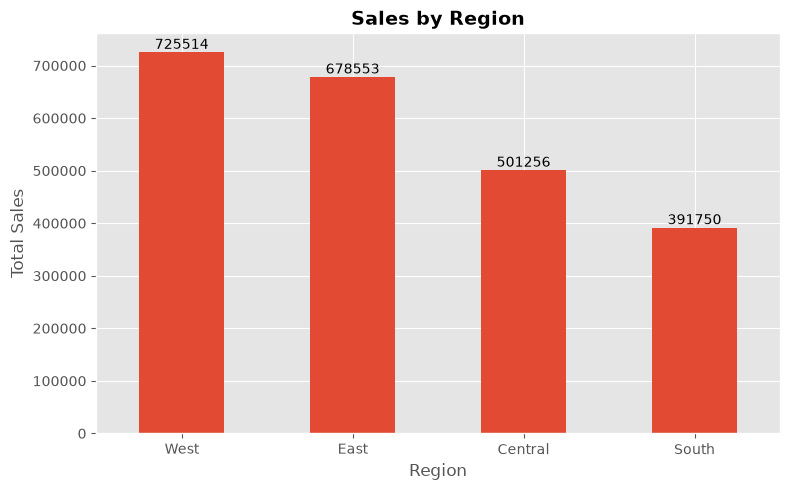

In [66]:

sales_by_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

ax = sales_by_region.plot(kind="bar")

plt.title("Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\sales_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
### Business Insight
'''
- The West region generated the highest sales among all regions.
- The East region also contributed significantly to total revenue.
- The South region recorded the lowest sales.
- The company may focus on improving sales performance in lower-performing regions while maintaining strong performance in high-revenue regions.
'''

'\n- The West region generated the highest sales among all regions.\n- The East region also contributed significantly to total revenue.\n- The South region recorded the lowest sales.\n- The company may focus on improving sales performance in lower-performing regions while maintaining strong performance in high-revenue regions.\n'

In [20]:
## Profit by Region

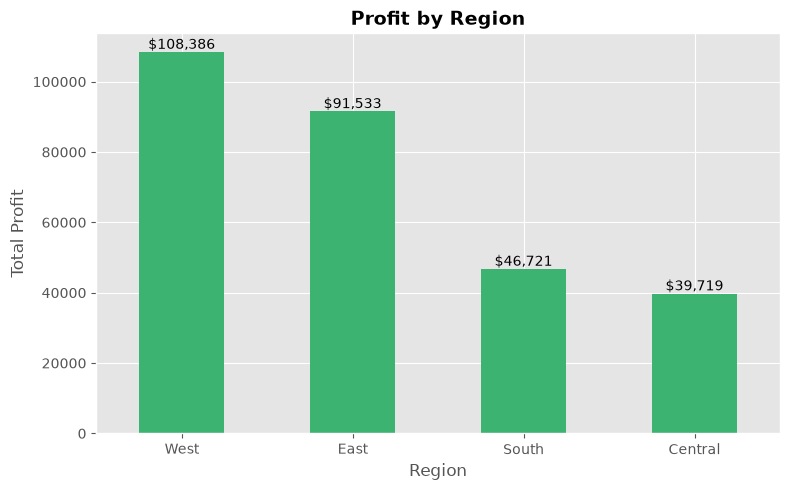

In [68]:
profit_by_region = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

ax = profit_by_region.plot(
    kind="bar",
    color="mediumseagreen"
)

plt.title("Profit by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)

labels = [f"${value:,.0f}" for value in profit_by_region.values]

for container in ax.containers:
    ax.bar_label(container, labels=labels)

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\profit_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
'''### Business Insight

- The West region generated the highest profit.
- The East region also contributed strong profitability.
- The Central and South regions generated comparatively lower profits.
- The company should focus on improving profitability in lower-performing regions while maintaining growth in the high-profit regions.
'''

'### Business Insight\n\n- The West region generated the highest profit.\n- The East region also contributed strong profitability.\n- The Central and South regions generated comparatively lower profits.\n- The company should focus on improving profitability in lower-performing regions while maintaining growth in the high-profit regions.\n'

In [23]:
## Sales by Segment

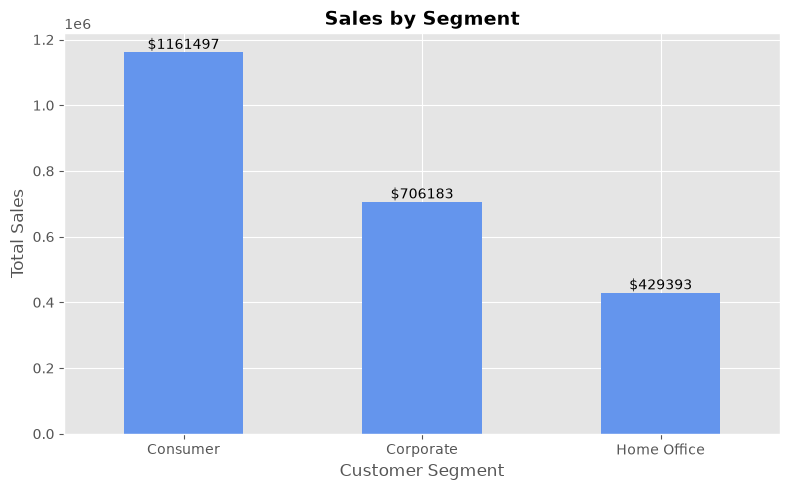

In [69]:
sales_by_segment = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = sales_by_segment.plot(
    kind="bar",
    color="cornflowerblue"
)

plt.title("Sales by Segment", fontsize=14, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\sales_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
'''### Business Insight

- The Consumer segment generated the highest sales among all customer segments.
- The Corporate segment contributed the second-highest sales.
- The Home Office segment generated the lowest sales.
- The Consumer segment represents the largest revenue opportunity, while the Home Office segment has potential for future growth through targeted marketing and promotions.
'''

'### Business Insight\n\n- The Consumer segment generated the highest sales among all customer segments.\n- The Corporate segment contributed the second-highest sales.\n- The Home Office segment generated the lowest sales.\n- The Consumer segment represents the largest revenue opportunity, while the Home Office segment has potential for future growth through targeted marketing and promotions.\n'

In [28]:
## Monthly Sales Trend

In [32]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

In [33]:
df["Order Date"].dtype


dtype('<M8[us]')

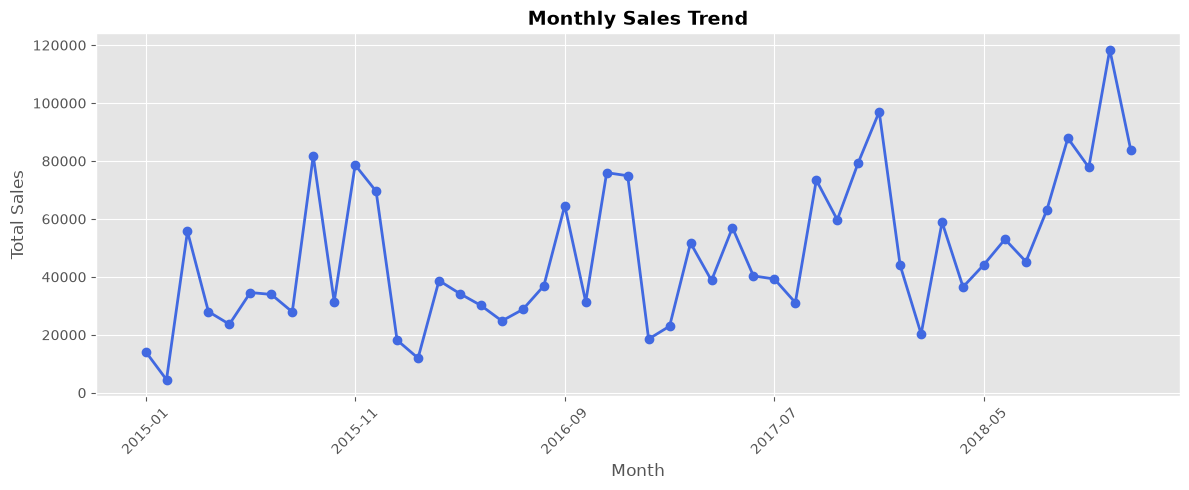

In [70]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))

ax = monthly_sales.plot(
    kind="line",
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\monthly_sales_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [35]:
## Monthly Profit Trend

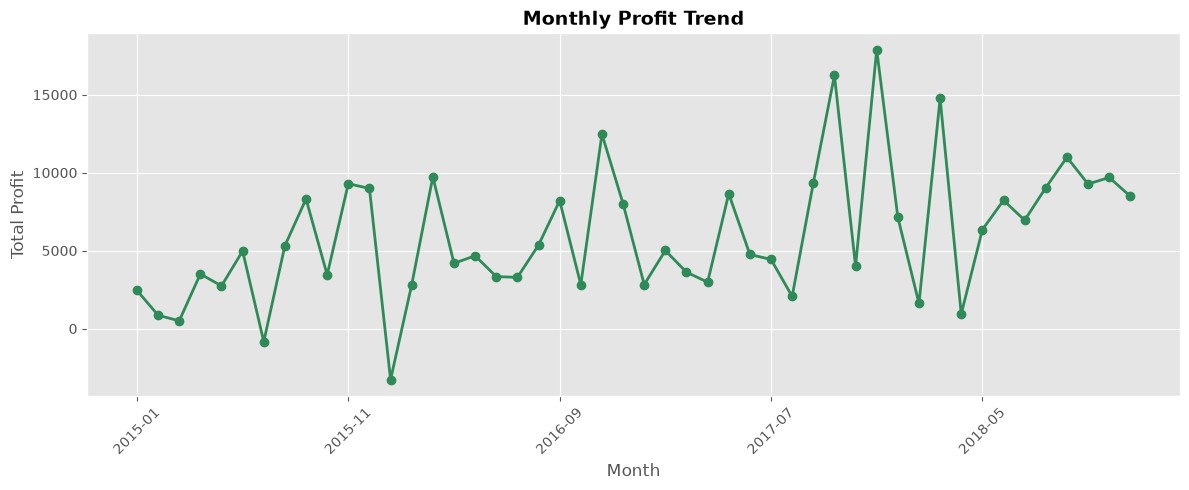

In [71]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")

monthly_profit = df.groupby(df["Order Date"].dt.to_period("M"))["Profit"].sum()

monthly_profit.index = monthly_profit.index.astype(str)

plt.figure(figsize=(12,5))

monthly_profit.plot(
    kind="line",
    marker="o",
    linewidth=2,
    color="seagreen"
)

plt.title("Monthly Profit Trend", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\monthly_profit_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
"""
### Business Insight

- Monthly profit fluctuates over time, indicating changes in business performance.
- Certain months generated significantly higher profits, suggesting the impact of seasonal demand or successful sales campaigns.
- A few months recorded relatively lower profits, which may be due to higher discounts, increased costs, or reduced sales.
- Analyzing these trends helps the business plan inventory, pricing strategies, and marketing activities more effectively.
    """

'\n### Business Insight\n\n- Monthly profit fluctuates over time, indicating changes in business performance.\n- Certain months generated significantly higher profits, suggesting the impact of seasonal demand or successful sales campaigns.\n- A few months recorded relatively lower profits, which may be due to higher discounts, increased costs, or reduced sales.\n- Analyzing these trends helps the business plan inventory, pricing strategies, and marketing activities more effectively.\n    '

In [38]:
## Top 10 Customers

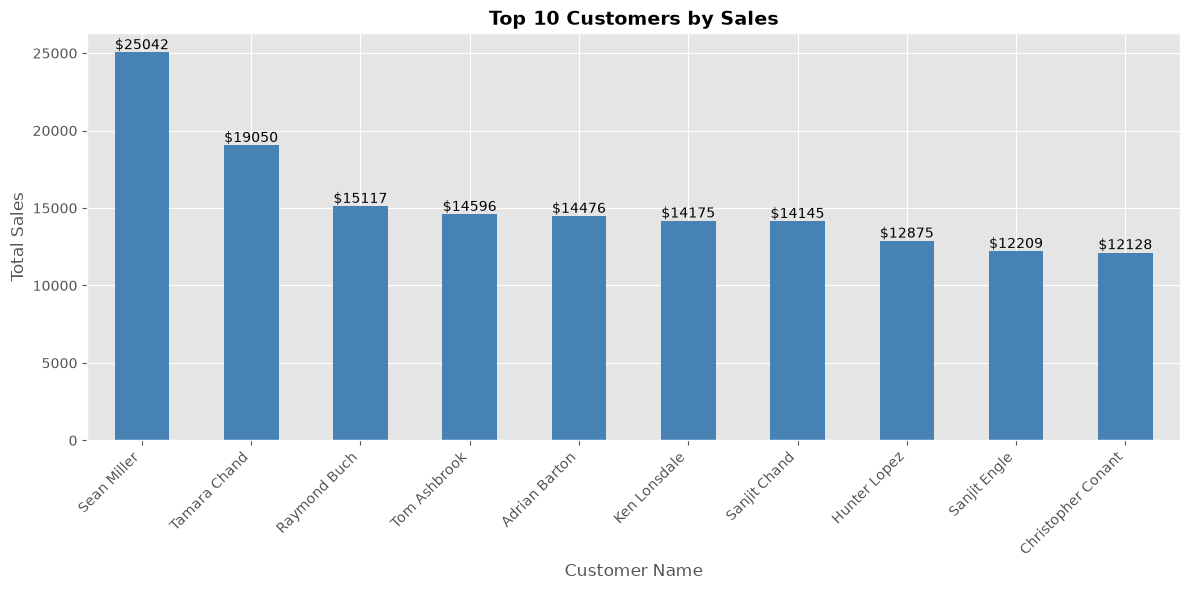

In [72]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

ax = top_customers.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\top_10_customers.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
''' 
### Business Insight

- A small group of customers contributes a significant portion of total sales.
- The top 10 customers are the company's most valuable customers in terms of revenue.
- Building strong relationships and loyalty programs for these customers can help maximize long-term revenue.
- The company should also focus on expanding its customer base to reduce dependency on a few high-value customers.
'''

" \n### Business Insight\n\n- A small group of customers contributes a significant portion of total sales.\n- The top 10 customers are the company's most valuable customers in terms of revenue.\n- Building strong relationships and loyalty programs for these customers can help maximize long-term revenue.\n- The company should also focus on expanding its customer base to reduce dependency on a few high-value customers.\n"

In [41]:
## Top 10 Products

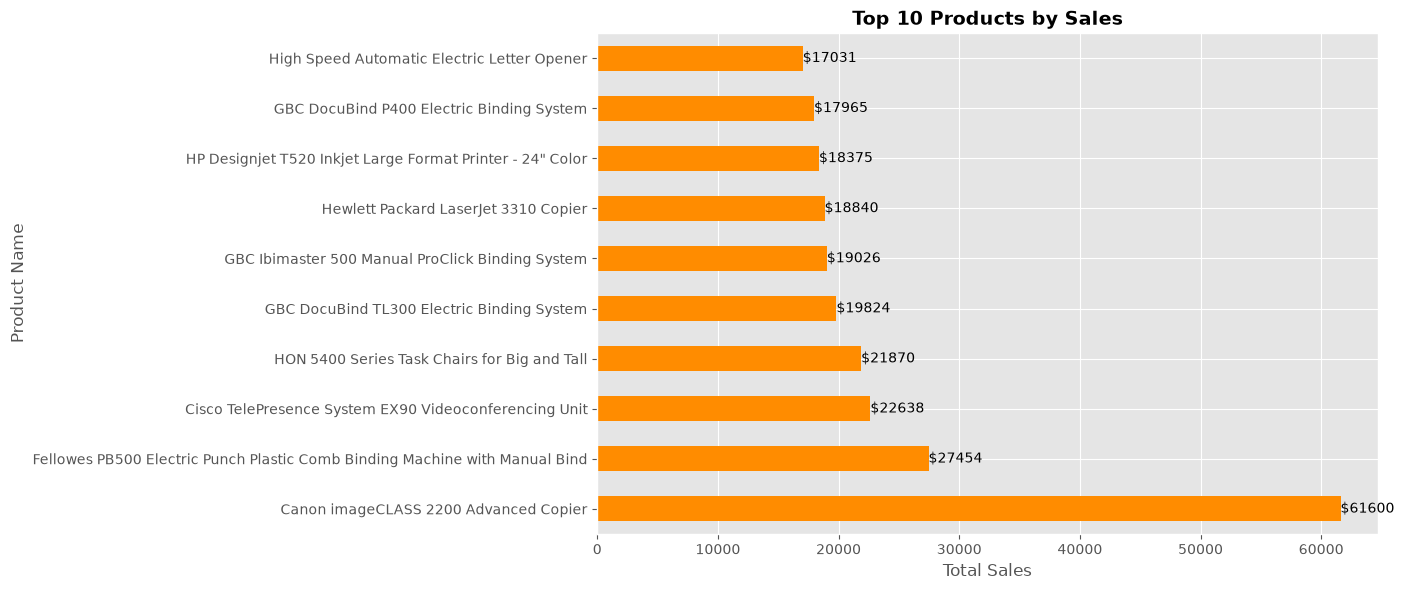

In [73]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(14,6))

ax = top_products.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

for container in ax.containers:
    ax.bar_label(container, fmt="$%.0f")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\top_10_products.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
""" 
### Business Insight

- The top 10 products contribute a significant share of the company's total sales.
- High-performing products should be prioritized for inventory management and promotional campaigns.
- Understanding the characteristics of these products can help identify opportunities to improve the sales of similar products.
- Regular monitoring of product performance can support better pricing and inventory decisions.
"""

" \n### Business Insight\n\n- The top 10 products contribute a significant share of the company's total sales.\n- High-performing products should be prioritized for inventory management and promotional campaigns.\n- Understanding the characteristics of these products can help identify opportunities to improve the sales of similar products.\n- Regular monitoring of product performance can support better pricing and inventory decisions.\n"

In [44]:
## Sales Distribution (Histogram)


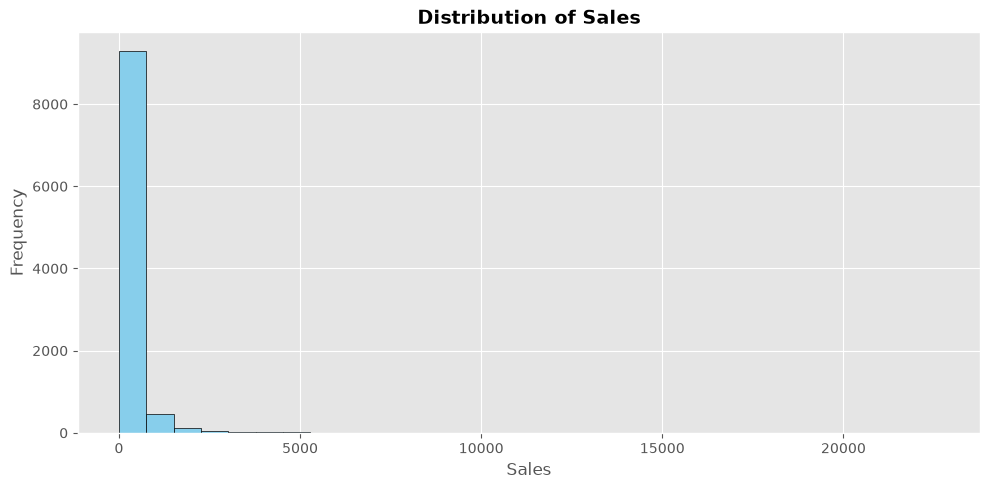

In [77]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Sales"],
    bins=30,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Sales", fontsize=14, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\sales_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
""" 
### Business Insight

- Most sales transactions are concentrated in the lower sales range.
- A few transactions have exceptionally high sales values, creating a right-skewed distribution.
- The presence of high-value orders indicates that a small number of purchases contribute significantly to overall revenue.
- This distribution suggests the business relies on many small transactions along with a few large-value orders.
"""

' \n### Business Insight\n\n- Most sales transactions are concentrated in the lower sales range.\n- A few transactions have exceptionally high sales values, creating a right-skewed distribution.\n- The presence of high-value orders indicates that a small number of purchases contribute significantly to overall revenue.\n- This distribution suggests the business relies on many small transactions along with a few large-value orders.\n'

In [47]:
# ## Sales Box Plot

C:\Users\muska\AppData\Local\Temp\ipykernel_15884\1760790400.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Sales"], vert=False)


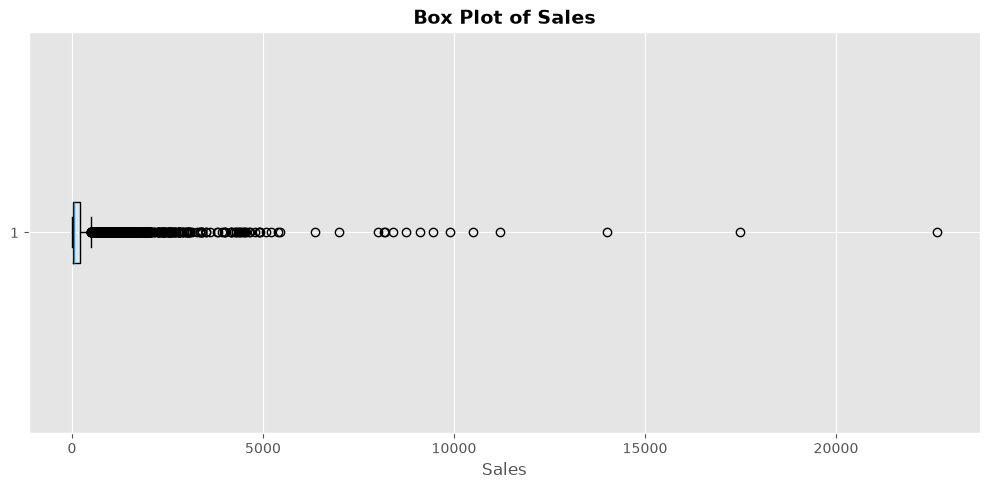

In [76]:
# without Seaborn

plt.figure(figsize=(10,5))

plt.boxplot(df["Sales"], vert=False)

plt.title("Box Plot of Sales", fontsize=14, fontweight="bold")
plt.xlabel("Sales")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\sales_boxplot1.png", dpi=300, bbox_inches="tight")
plt.show()

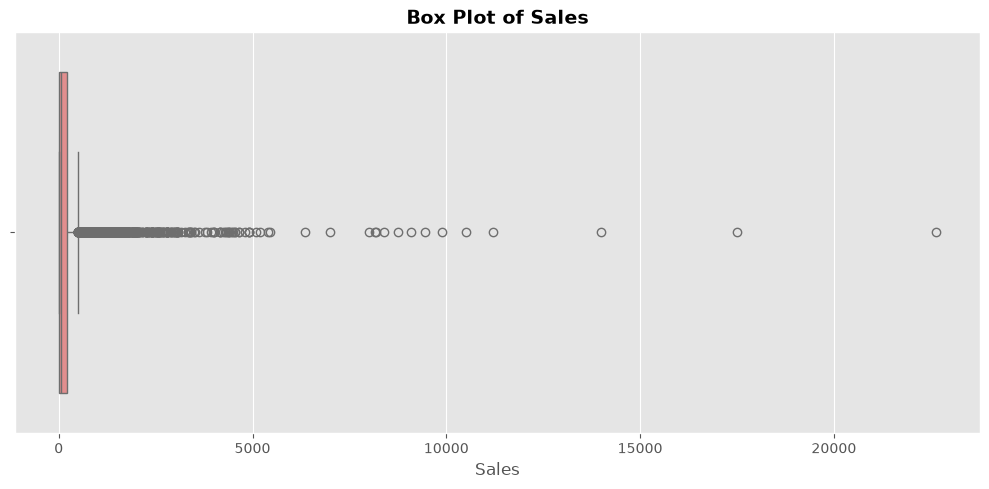

In [75]:
# With Seaborn

plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Sales"],
    color="lightcoral"
)

plt.title("Box Plot of Sales", fontsize=14, fontweight="bold")
plt.xlabel("Sales")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\sales_boxplot2.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
""" 
### Business Insight

- The box plot reveals the presence of several outliers in the Sales column.
- Most sales transactions are concentrated within a relatively small range, while a few orders have exceptionally high sales values.
- The right-skewed distribution indicates that large-value transactions are less frequent but contribute significantly to total revenue.
- Identifying these high-value orders can help the business understand key customers and premium products driving sales.
"""

' \n### Business Insight\n\n- The box plot reveals the presence of several outliers in the Sales column.\n- Most sales transactions are concentrated within a relatively small range, while a few orders have exceptionally high sales values.\n- The right-skewed distribution indicates that large-value transactions are less frequent but contribute significantly to total revenue.\n- Identifying these high-value orders can help the business understand key customers and premium products driving sales.\n'

In [55]:
## Correlation Heatmap

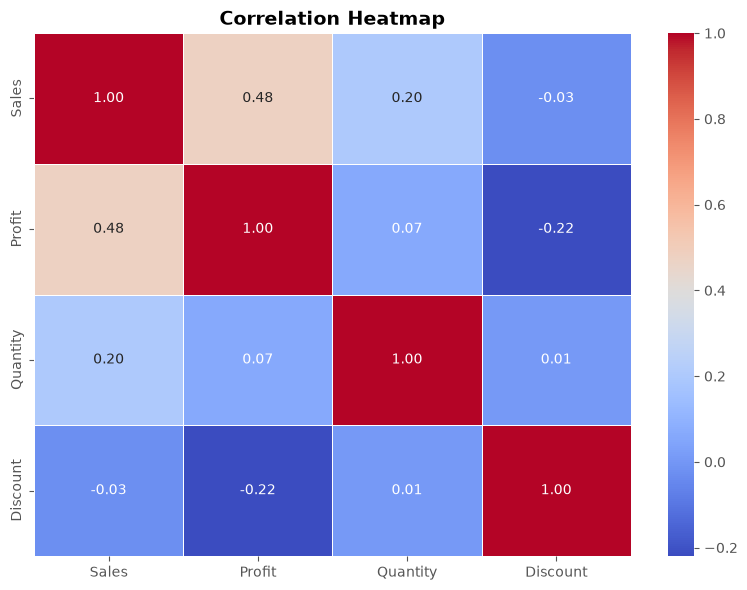

In [74]:
correlation = df[["Sales", "Profit", "Quantity", "Discount"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(r"C:\Users\muska\OneDrive\Documents\Data-Analyst-Portfolio\Ecommerce-Sales-Analysis\images\correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
"""### Business Insight

- Sales and Profit show a positive correlation, indicating that higher sales generally lead to higher profits.
- Discount has a negative correlation with Profit, suggesting that higher discounts tend to reduce profitability.
- Quantity has a weak positive correlation with Sales and Profit, indicating that selling more units contributes to revenue but is not the only factor affecting profit.
- The heatmap helps identify relationships between key business metrics and supports better pricing and sales strategies.
"""